# Assignment Code: DA-AG-018

# Anomaly Detection & Time Series |

# Assignment

Instructions: Carefully read each question. Use Google Docs, Microsoft Word, or a similar tool
to create a document where you type out each question along with its answer. Save the
document as a PDF, and then upload it to the LMS. Please do not zip or archive the files before
uploading them. Each question carries 20 marks.

Question 1:  What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.


Question 3: What are the key components of a Time Series? Explain each with one
example.

Question 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?

Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.

Dataset:
● NYC Taxi Fare Data
● AirPassengers Dataset
Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components
(Include your Python code and output in the code box below.)

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot.
(Include your Python code and output in the code box below.)
  
Question 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.
(Include your Python code and output in the code box below.)

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.
(Include your Python code and output in the code box below.)

Question 10: You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:
● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?
● How would you validate and monitor the performance over time?
● How would this solution help business decisions or operations?
(Include your Python code and output in the code box below.)


Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.
Answer:
Anomaly Detection

Anomaly Detection is a data mining technique used to identify unusual patterns or rare observations that significantly deviate from the majority of the data. These unusual observations are called anomalies or outliers.

It is widely used in:

Fraud detection

Network intrusion detection

Medical diagnostics

Fault detection in machines

Financial risk monitoring

Types of Anomalies
1. Point Anomaly

A single observation that is significantly different from the rest of the data.

Example:
If average daily sales = ₹10,000
One day sales = ₹1,00,000 → Point anomaly

2. Contextual Anomaly

An observation that is anomalous in a specific context (time, location, season).

Example:
Temperature = 35°C
Normal in summer
Abnormal in winter → Contextual anomaly

3. Collective Anomaly

A collection of related observations that are abnormal together, even if individual points are not abnormal.

Example:
Sudden continuous spike in network traffic for 2 hours may indicate a cyber attack.

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
Answer:
| Algorithm                  | Approach                                           | Suitable Use Case                 | Advantages                        | Limitations                                  |
| -------------------------- | -------------------------------------------------- | --------------------------------- | --------------------------------- | -------------------------------------------- |
| Isolation Forest           | Randomly isolates data points using decision trees | High-dimensional large datasets   | Fast and scalable                 | May not capture local density anomalies well |
| DBSCAN                     | Density-based clustering                           | Spatial data, irregular clusters  | Detects arbitrary shaped clusters | Sensitive to parameter selection             |
| Local Outlier Factor (LOF) | Compares local density of point to neighbors       | Detecting local density anomalies | Good for local anomalies          | Computationally expensive                    |


Question 3: What are the key components of a Time Series? Explain each with one example.
Answer:

A Time Series is a sequence of observations recorded over time.

1. Trend

Long-term upward or downward movement.

Example: Increase in smartphone sales over years.

2. Seasonality

Repeating patterns at fixed intervals.

Example: Ice cream sales increase every summer.

3. Cyclical Component

Fluctuations over long periods not fixed.

Example: Economic boom and recession cycles.

4. Residual (Noise)

Random variation not explained by trend or seasonality.

Example: Sudden one-day sales spike due to event.

Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?
Answer:
Stationary Time Series

A time series is stationary if:

Mean is constant over time

Variance is constant

Autocovariance does not depend on time

Testing Stationarity

We use Augmented Dickey-Fuller (ADF) Test.

If p-value < 0.05 → Series is stationary

In [9]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv('/content/AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

result = adfuller(df['#Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


Transforming Non-Stationary Series

Differencing

Log Transformation

Seasonal Differencing

In [11]:
import numpy as np
df_log = df['#Passengers'].apply(lambda x: np.log(x))
df_diff = df_log.diff().dropna()

Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.
Answer:
| Model        | Structure                   | Application                    |
| ------------ | --------------------------- | ------------------------------ |
| AR(p)        | Depends on past values      | Short-term forecasting         |
| MA(q)        | Depends on past errors      | Noise smoothing                |
| ARIMA(p,d,q) | AR + Differencing + MA      | Non-seasonal time series       |
| SARIMA       | ARIMA + Seasonal components | Seasonal time series           |
| SARIMAX      | SARIMA + External variables | Forecast with external factors |


Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components (Include your Python code and output in the code box below.)

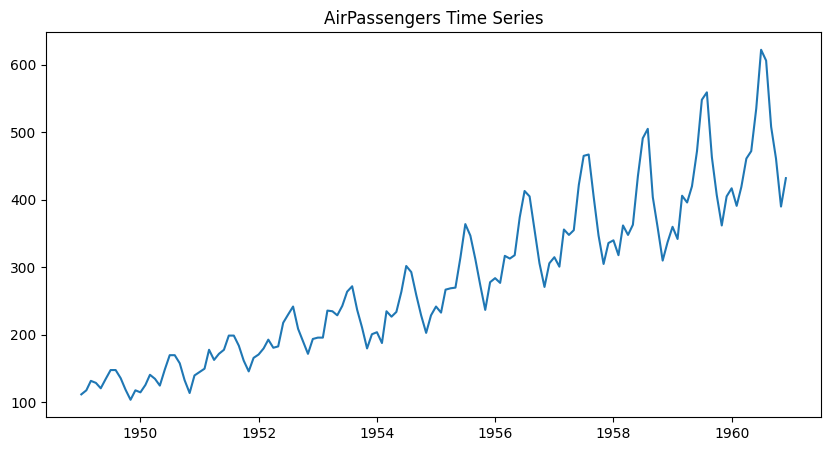

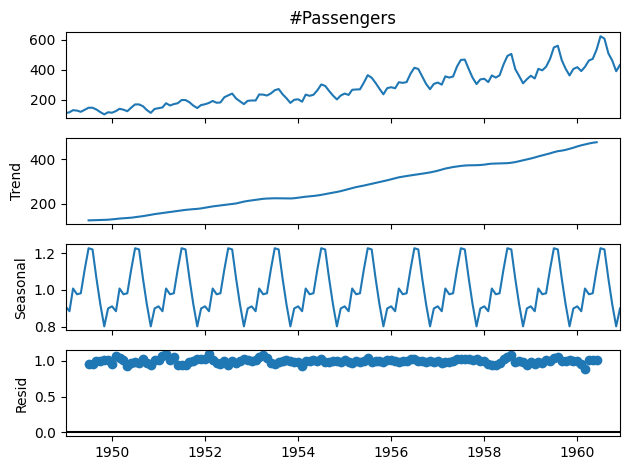

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load Dataset
df = pd.read_csv('/content/AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot Original Series
plt.figure(figsize=(10,5))
plt.plot(df['#Passengers'])
plt.title("AirPassengers Time Series")
plt.show()

# Decomposition
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative')

decomposition.plot()
plt.show()

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot. (Include your Python code and output in the code box below.)

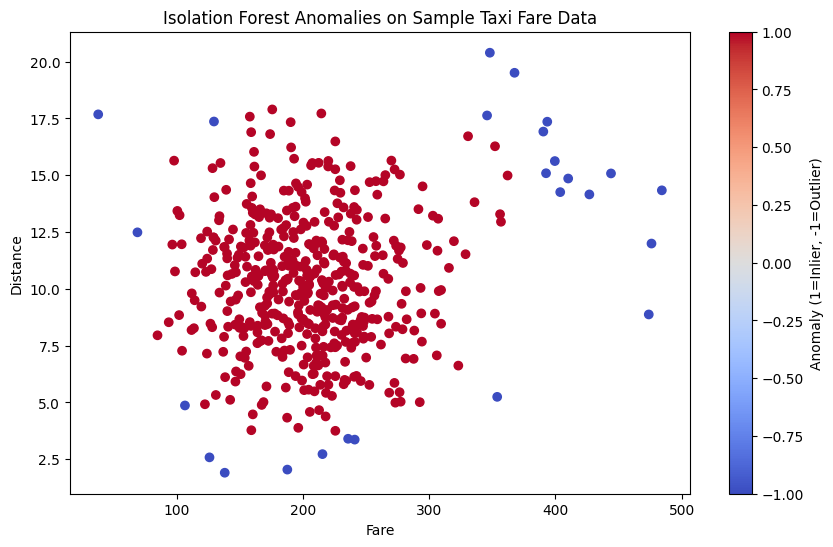

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate sample taxi-like data
np.random.seed(42)
fare = np.random.normal(200, 50, 500)
distance = np.random.normal(10, 3, 500)

data = np.column_stack((fare, distance))

# Add anomalies by shifting some data points significantly
data[480:500, 0] += 200 # increase fare for anomalies
data[480:500, 1] += 5 # increase distance for anomalies

model = IsolationForest(contamination=0.05, random_state=42) # Set random_state for reproducibility
pred = model.fit_predict(data)

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(data[:,0], data[:,1], c=pred, cmap='coolwarm') # '1' for inliers, '-1' for outliers
plt.xlabel("Fare")
plt.ylabel("Distance")
plt.title("Isolation Forest Anomalies on Sample Taxi Fare Data")
plt.colorbar(label='Anomaly (1=Inlier, -1=Outlier)')
plt.show()

Question 8: Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results. (Include your Python code and output in the code box below.)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


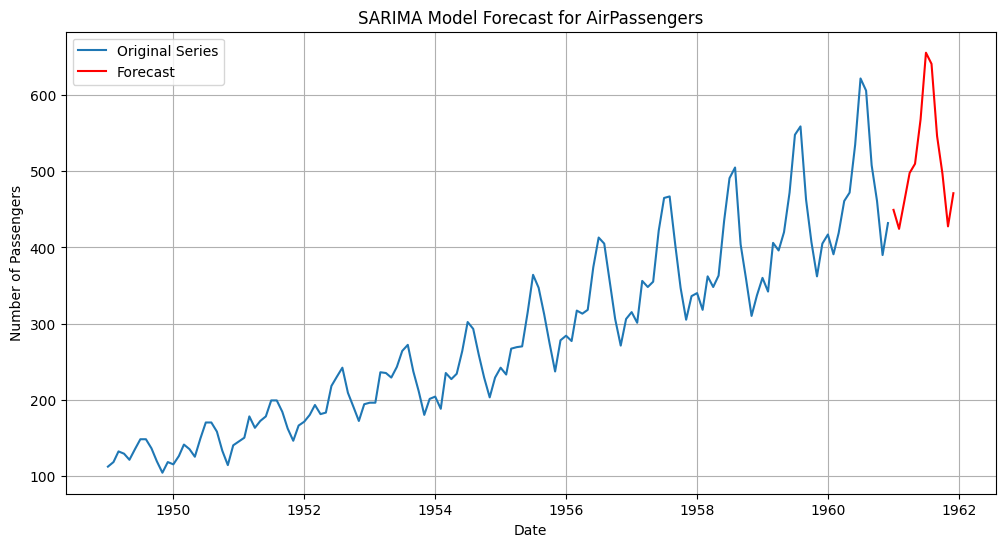

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure df is loaded (it should be from previous steps, but adding for robustness)
if 'df' not in locals():
    df = pd.read_csv('/content/AirPassengers.csv')
    df['Month'] = pd.to_datetime(df['Month'])
    df.set_index('Month', inplace=True)

model = SARIMAX(df['#Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

results = model.fit(disp=False)

# Forecast the next 12 months
forecast_steps = 12
forecast = results.predict(start=len(df), end=len(df) + forecast_steps - 1)

# Create a date index for the forecast (next 12 months after the last date in df)
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date, periods=forecast_steps + 1, freq='MS')[1:] # 'MS' for Month Start
forecast.index = forecast_index

plt.figure(figsize=(12,6))
plt.plot(df['#Passengers'], label='Original Series')
plt.plot(forecast, label='Forecast', color='red')
plt.title('SARIMA Model Forecast for AirPassengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib. (Include your Python code and output in the code box below.)

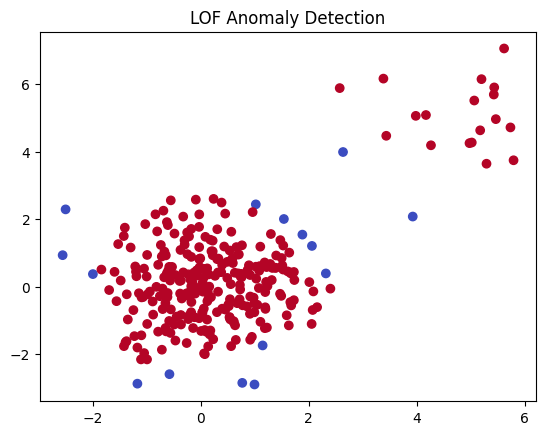

In [14]:
from sklearn.neighbors import LocalOutlierFactor

X = np.random.randn(300,2)
X[280:300] += 5

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='coolwarm')
plt.title("LOF Anomaly Detection")
plt.show()

Question 10: You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:

● How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?

● Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)?

● How would you validate and monitor the performance over time?

● How would this solution help business decisions or operations?

Answer:
1. Anomaly Detection Approach

For streaming data, I would use Isolation Forest because:

It is fast and scalable

Works well with high-dimensional data

Suitable for real-time detection

LOF can be used for local density changes.
DBSCAN is useful for detecting abnormal consumption clusters by region.

2. Time Series Model

I would use SARIMAX because:

Energy data has seasonality (daily and weekly)

Weather impacts energy demand

It supports external variables

3. Validation & Monitoring

Rolling window validation

Evaluate RMSE and MAE

Monitor model drift

Retrain periodically

Use real-time dashboards

4. Business Benefits

Prevent power outages

Detect equipment failure early

Optimize energy distribution

Reduce operational costs

Improve grid reliability

In [15]:
def detect_anomaly(new_data, model):
    prediction = model.predict(new_data)
    return prediction